Research Question: 

Research Topic: The impact of a baseball player’s batting side on their hitting success.  
Research Question: Do left-handed batters have a higher overall batting average than right-handed batters? 

In [ ]:
import pandas as pd
from openpyxl import load_workbook
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
df = pd.read_csv(Path.cwd() / "data" / "processed" / "left_right" / "all_hitters_historical.csv")

In [89]:
df.columns

Index(['id', 'first_name', 'last_name', 'current_team', 'position',
       'mlb_debut', 'bat_side', 'pitch_hand', 'type', 'group', 'season', 'age',
       'gamesPlayed', 'groundOuts', 'airOuts', 'runs', 'doubles', 'triples',
       'homeRuns', 'strikeOuts', 'baseOnBalls', 'intentionalWalks', 'hits',
       'hitByPitch', 'avg', 'atBats', 'obp', 'slg', 'ops', 'caughtStealing',
       'stolenBases', 'stolenBasePercentage', 'caughtStealingPercentage',
       'groundIntoDoublePlay', 'numberOfPitches', 'plateAppearances',
       'totalBases', 'rbi', 'leftOnBase', 'sacBunts', 'sacFlies', 'babip',
       'groundOutsToAirouts', 'catchersInterference', 'atBatsPerHomeRun'],
      dtype='str')

## Batting Side Analysis

This section compares left-handed and right-handed batters using batting average (`avg`) as the main success metric.

The charts below are split into separate cells so each figure is easier to read and present: one distribution view, one spread view, and one season trend view.

In [90]:
import pandas as pd
from IPython.display import display

# Clean and standardize the analysis set
analysis_df = df.copy()

for column in ["avg", "hits", "atBats", "season", "gamesPlayed", "homeRuns", "strikeOuts"]:
    if column in analysis_df.columns:
        analysis_df[column] = pd.to_numeric(analysis_df[column], errors="coerce")

analysis_df["bat_side"] = (
    analysis_df["bat_side"]
    .astype("string")
    .str.strip()
    .str.upper()
    .fillna("UNKNOWN")
)

bat_side_counts = analysis_df["bat_side"].value_counts().reindex(["LEFT", "RIGHT", "SWITCH"], fill_value=0)
display(bat_side_counts.rename_axis("bat_side").to_frame("records"))

comparison_df = analysis_df[analysis_df["bat_side"].isin(["LEFT", "RIGHT"])].copy()
comparison_df = comparison_df.dropna(subset=["avg", "hits", "atBats"])
comparison_df = comparison_df[comparison_df["atBats"] > 0].copy()

side_summary = (
    comparison_df.groupby("bat_side")
    .agg(
        records=("id", "size"),
        players=("id", "nunique"),
        seasons=("season", "nunique"),
        mean_avg=("avg", "mean"),
        median_avg=("avg", "median"),
        std_avg=("avg", "std"),
        total_hits=("hits", "sum"),
        total_at_bats=("atBats", "sum"),
    )
    .reindex(["LEFT", "RIGHT"])
 )

side_summary["weighted_avg"] = side_summary["total_hits"] / side_summary["total_at_bats"]

if {"LEFT", "RIGHT"}.issubset(side_summary.index):
    right_weighted_avg = side_summary.loc["RIGHT", "weighted_avg"]
    side_summary["weighted_avg_gap_vs_RIGHT"] = side_summary["weighted_avg"] - right_weighted_avg
    left_vs_right_gap = side_summary.loc["LEFT", "weighted_avg"] - right_weighted_avg
    mean_gap = side_summary.loc["LEFT", "mean_avg"] - side_summary.loc["RIGHT", "mean_avg"]
    display(
        side_summary.style.format({
            "mean_avg": "{:.3f}",
            "median_avg": "{:.3f}",
            "std_avg": "{:.3f}",
            "weighted_avg": "{:.3f}",
            "weighted_avg_gap_vs_RIGHT": "{:+.3f}",
            "total_hits": "{:.0f}",
            "total_at_bats": "{:.0f}",
        })
    )
    print(f"Weighted batting average gap (LEFT - RIGHT): {left_vs_right_gap:+.3f}")
    print(f"Difference in row-level mean AVG (LEFT - RIGHT): {mean_gap:+.3f}")
else:
    display(side_summary)
    print("Both left- and right-handed batters are required for the comparison.")

,records
bat_side,
LEFT,4269
RIGHT,7345
SWITCH,1727


,records,players,seasons,mean_avg,median_avg,std_avg,total_hits,total_at_bats,weighted_avg,weighted_avg_gap_vs_RIGHT
bat_side,,,,,,,,,,
LEFT,4255,902,21,0.234,0.244,0.071,275184,1071601,0.257,-0.001
RIGHT,7316,1503,21,0.233,0.244,0.076,458113,1777782,0.258,+0.000


Weighted batting average gap (LEFT - RIGHT): -0.001
Difference in row-level mean AVG (LEFT - RIGHT): +0.000


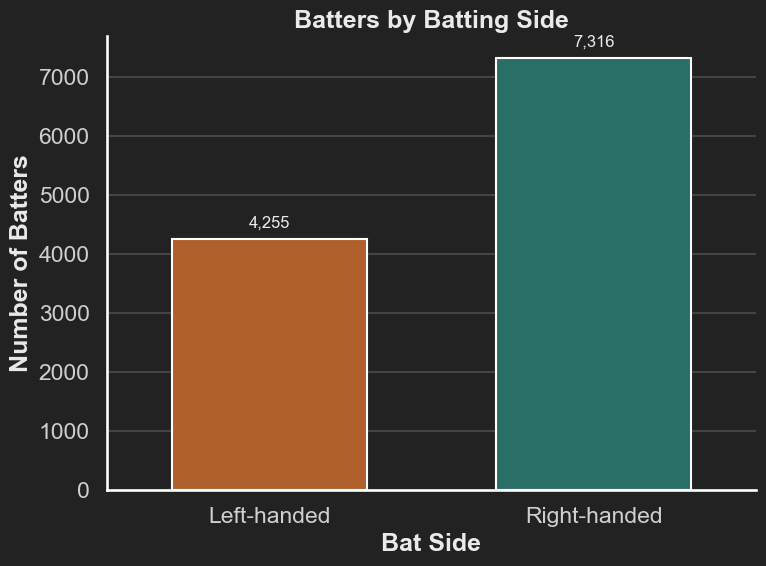

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count chart for batting side presence
side_counts = comparison_df["bat_side"].value_counts().reindex(["LEFT", "RIGHT"], fill_value=0).reset_index()
side_counts.columns = ["bat_side", "count"]

side_palette = {"LEFT": "#c65d15", "RIGHT": "#1f7a6e"}
side_labels = {"LEFT": "Left-handed", "RIGHT": "Right-handed"}

sns.set_theme(
    style="darkgrid",
    context="talk",
    rc={
        "axes.facecolor": "#222222",
        "figure.facecolor": "#222222",
        "axes.labelcolor": "#eaeaea",
        "text.color": "#eaeaea",
        "xtick.color": "#cfcfcf",
        "ytick.color": "#cfcfcf",
        "grid.color": "#444444",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelweight": "semibold",
    },
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=side_counts,
    x="bat_side",
    y="count",
    hue="bat_side",
    order=["LEFT", "RIGHT"],
    hue_order=["LEFT", "RIGHT"],
    palette=side_palette,
    dodge=False,
    legend=False,
    ax=ax,
    width=0.6,
)
ax.set_title("Batters by Batting Side")
ax.set_xlabel("Bat Side")
ax.set_ylabel("Number of Batters")
ax.set_xticks([0, 1])
ax.set_xticklabels([side_labels["LEFT"], side_labels["RIGHT"]])

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f"{int(height):,}",
        (bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=12,
        xytext=(0, 6),
        textcoords="offset points",
    )

sns.despine()
plt.tight_layout()
plt.show()

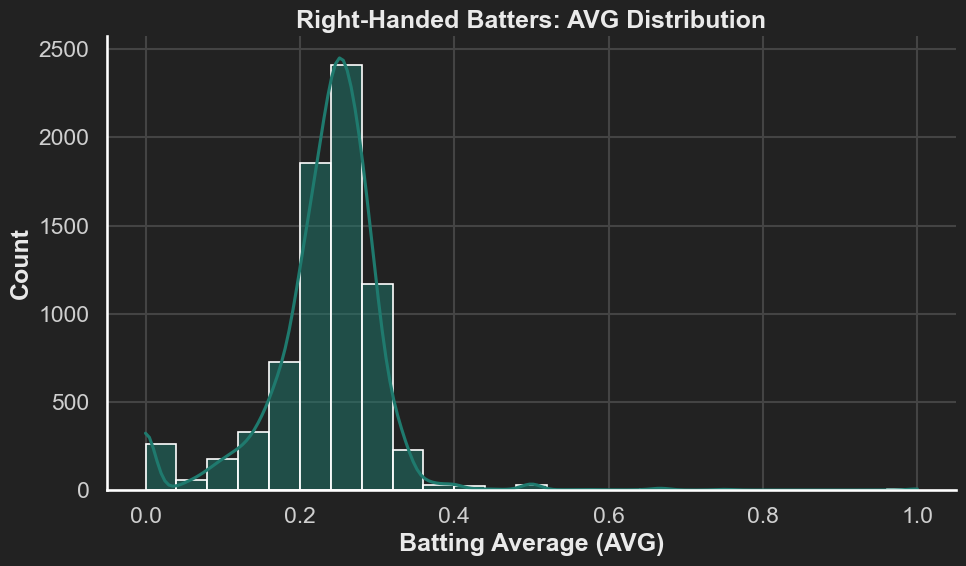

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# AVG distribution for right-handed batters only
plot_df = comparison_df.loc[comparison_df["bat_side"] == "RIGHT", ["avg"]].copy().dropna()
sns.set_theme(
    style="darkgrid",
    context="talk",
    rc={
        "axes.facecolor": "#222222",
        "figure.facecolor": "#222222",
        "axes.labelcolor": "#eaeaea",
        "text.color": "#eaeaea",
        "xtick.color": "#cfcfcf",
        "ytick.color": "#cfcfcf",
        "grid.color": "#444444",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelweight": "semibold",
    },
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=plot_df,
    x="avg",
    bins=25,
    kde=True,
    color="#1f7a6e",
    edgecolor="white",
    linewidth=1.2,
    ax=ax,
 )
ax.set_title("Right-Handed Batters: AVG Distribution")
ax.set_xlabel("Batting Average (AVG)")
ax.set_ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

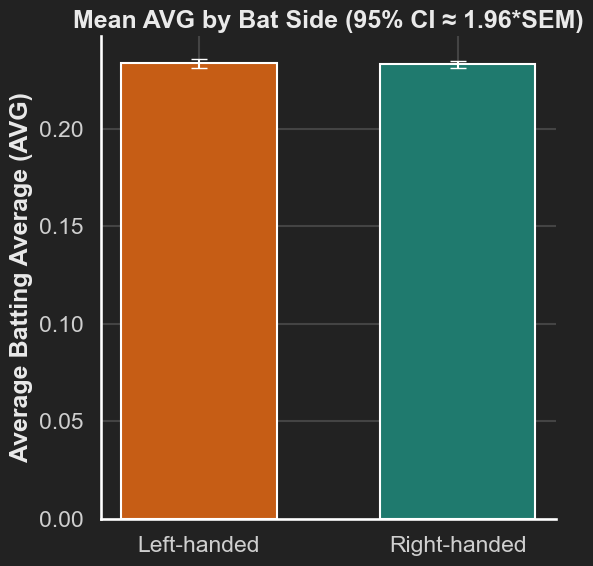

In [93]:
# Bar chart: mean AVG by bat side with 95% CI approximated by 1.96*SEM (~2*SEM)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
side_palette = {"LEFT": "#c65d15", "RIGHT": "#1f7a6e"}
side_labels = {"LEFT": "Left-handed", "RIGHT": "Right-handed"}
bar_df = comparison_df.dropna(subset=['avg']).copy()
# Compute mean and SEM per side
stats = bar_df.groupby('bat_side')['avg'].agg(['mean', 'count', 'std']).reindex(['LEFT', 'RIGHT'])
stats['sem'] = stats['std'] / np.sqrt(stats['count'])
stats['ci95'] = 1.96 * stats['sem']
fig, ax = plt.subplots(figsize=(6, 6))
x = np.arange(len(stats))
colors = [side_palette.get(s, '#777777') for s in stats.index]
bars = ax.bar(x, stats['mean'], color=colors, edgecolor='white', width=0.6, zorder=2)
# Plot 95% CI error bars (1.96*SEM)
ax.errorbar(x, stats['mean'], yerr=stats['ci95'], fmt='none', ecolor='white', elinewidth=1.5, capsize=6, zorder=3)
ax.set_xticks(x)
ax.set_xticklabels([side_labels.get(s, s) for s in stats.index])
ax.set_ylabel('Average Batting Average (AVG)')
ax.set_title('Mean AVG by Bat Side (95% CI ≈ 1.96*SEM)')
ax.set_facecolor('#222222')
sns.despine()
plt.tight_layout()
plt.show()

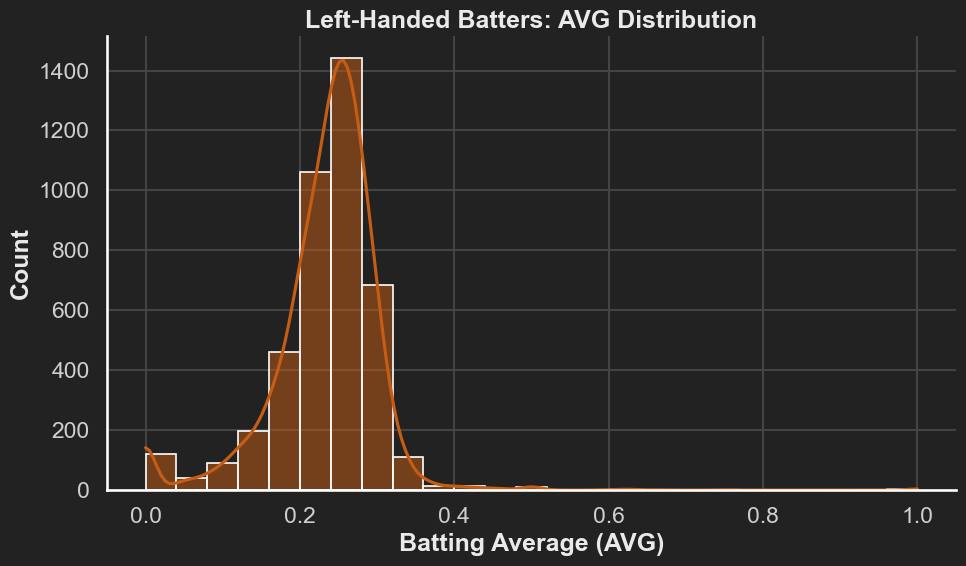

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# AVG distribution for left-handed batters only
plot_df = comparison_df.loc[comparison_df["bat_side"] == "LEFT", ["avg"]].copy().dropna()
sns.set_theme(
    style="darkgrid",
    context="talk",
    rc={
        "axes.facecolor": "#222222",
        "figure.facecolor": "#222222",
        "axes.labelcolor": "#eaeaea",
        "text.color": "#eaeaea",
        "xtick.color": "#cfcfcf",
        "ytick.color": "#cfcfcf",
        "grid.color": "#444444",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelweight": "semibold",
    },
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=plot_df,
    x="avg",
    bins=25,
    kde=True,
    color="#c65d15",
    edgecolor="white",
    linewidth=1.2,
    ax=ax,
 )
ax.set_title("Left-Handed Batters: AVG Distribution")
ax.set_xlabel("Batting Average (AVG)")
ax.set_ylabel("Count")
sns.despine()
plt.tight_layout()
plt.show()

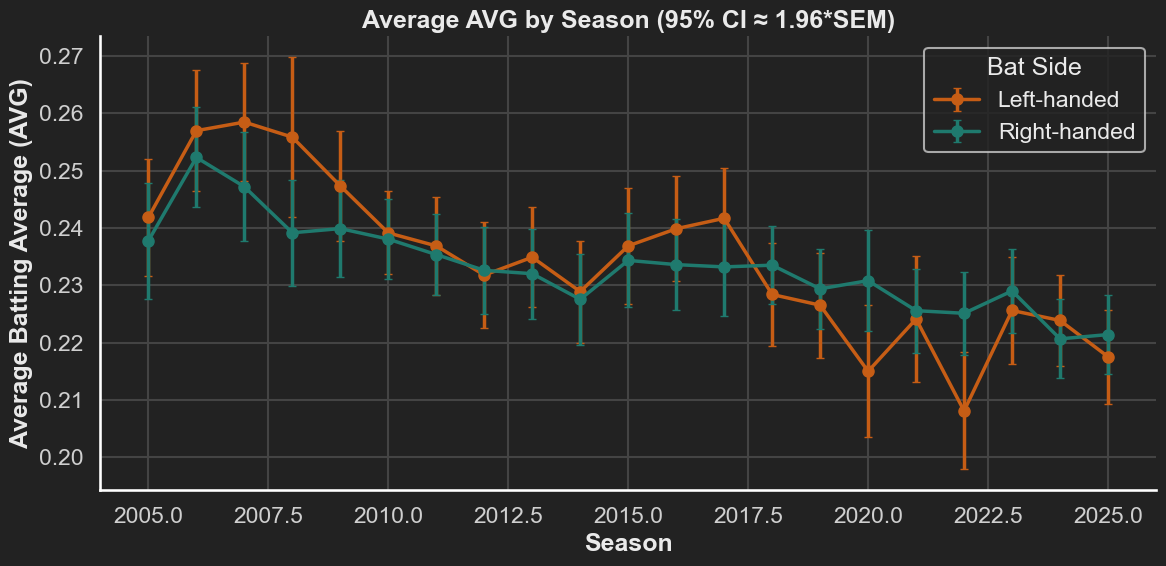

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Season trend of AVG by batting side
plot_df = comparison_df[["bat_side", "avg", "season"]].copy().dropna(subset=["avg", "season"])
plot_df["season"] = pd.to_numeric(plot_df["season"], errors="coerce")
plot_df = plot_df.dropna(subset=["season"])
side_palette = {"LEFT": "#c65d15", "RIGHT": "#1f7a6e"}
side_labels = {"LEFT": "Left-handed", "RIGHT": "Right-handed"}
sns.set_theme(
    style="darkgrid",
    context="talk",
    rc={
        "axes.facecolor": "#222222",
        "figure.facecolor": "#222222",
        "axes.labelcolor": "#eaeaea",
        "text.color": "#eaeaea",
        "xtick.color": "#cfcfcf",
        "ytick.color": "#cfcfcf",
        "grid.color": "#444444",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelweight": "semibold",
    },
)

# Season trend with 95% CI error bars computed from SEM (1.96*SEM) — approx. ±2*SEM
season_stats = (
    plot_df.groupby(['season', 'bat_side'])['avg']
    .agg(avg_mean='mean', avg_std='std', n='count')
    .reset_index()
)
# compute SEM and 95% CI
import numpy as np
season_stats['sem'] = season_stats['avg_std'] / np.sqrt(season_stats['n'])
season_stats['ci95'] = 1.96 * season_stats['sem']
fig, ax = plt.subplots(figsize=(12, 6))
for side in ['LEFT', 'RIGHT']:
    s = season_stats[season_stats['bat_side'] == side].sort_values('season')
    if s.empty:
        continue
    ax.errorbar(
        s['season'],
        s['avg_mean'],
        yerr=s['ci95'].fillna(0),
        label=side_labels.get(side, side),
        marker='o',
        linewidth=2.5,
        markersize=8,
        color=side_palette.get(side),
        capsize=3,
    )
ax.set_title('Average AVG by Season (95% CI ≈ 1.96*SEM)')
ax.set_xlabel('Season')
ax.set_ylabel('Average Batting Average (AVG)')
ax.legend(title='Bat Side', frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

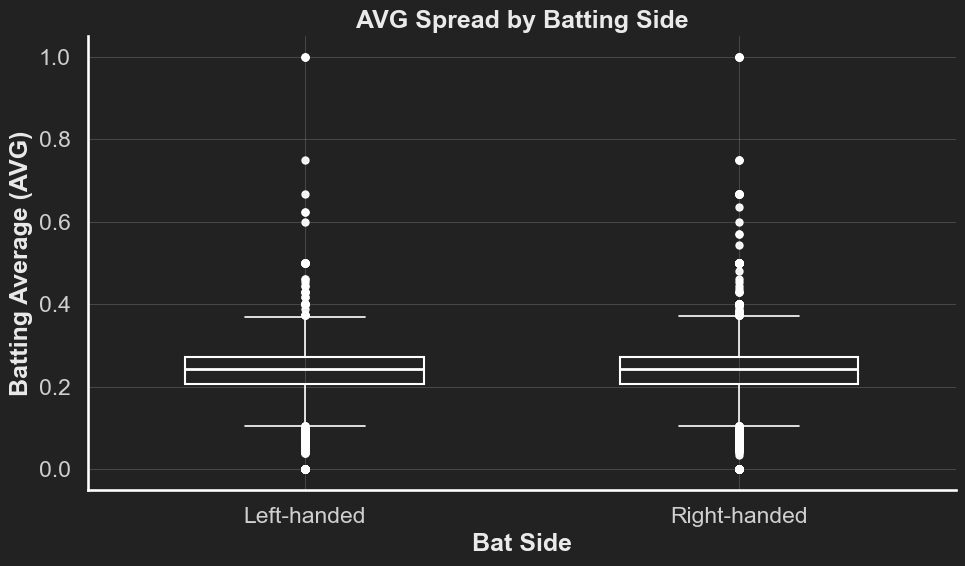

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot of AVG by batting side
plot_df = comparison_df[["bat_side", "avg"]].copy().dropna(subset=["avg"])
side_palette = {"LEFT": "#c65d15", "RIGHT": "#1f7a6e"}
side_labels = {"LEFT": "Left-handed", "RIGHT": "Right-handed"}
sns.set_theme(
    style="darkgrid",
    context="talk",
    rc={
        "axes.facecolor": "#222222",
        "figure.facecolor": "#222222",
        "axes.labelcolor": "#eaeaea",
        "text.color": "#eaeaea",
        "xtick.color": "#cfcfcf",
        "ytick.color": "#cfcfcf",
        "grid.color": "#444444",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelweight": "semibold",
    },
)

fig, ax = plt.subplots(figsize=(10, 6))
# Draw boxplot with all lines and fliers in white to suit dark background
sns.boxplot(
    data=plot_df,
    x="bat_side",
    y="avg",
    hue="bat_side",
    order=["LEFT", "RIGHT"],
    hue_order=["LEFT", "RIGHT"],
    palette=side_palette,
    dodge=False,
    width=0.55,
    fliersize=4,
    linewidth=1.5,
    legend=False,
    ax=ax,
    patch_artist=True,
    boxprops={"facecolor": "none", "edgecolor": "white", "linewidth": 1.5},
    whiskerprops={"color": "white", "linewidth": 1.2},
    capprops={"color": "white", "linewidth": 1.2},
    medianprops={"color": "white", "linewidth": 2},
    flierprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "white", "markersize": 5, "alpha": 0.95},
 )
# Ensure grid lines are visible and white for the dark theme
ax.grid(True, color="white", alpha=0.2, linewidth=0.6)
ax.set_title("AVG Spread by Batting Side")
ax.set_xlabel("Bat Side")
ax.set_ylabel("Batting Average (AVG)")
ax.set_xticks([0, 1])
ax.set_xticklabels([side_labels["LEFT"], side_labels["RIGHT"]])
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# Summary table: Left vs Right for AVG, OBP, SLG and sample size (N)
metrics = {'AVG': 'avg', 'OBP': 'obp', 'SLG': 'slg'}
# Ensure numeric where possible
for col in metrics.values():
    if col in comparison_df.columns:
        comparison_df[col] = pd.to_numeric(comparison_df[col], errors='coerce')
# Compute means by side
side_means = {}
for metric, col in metrics.items():
    if col in comparison_df.columns:
        grp = comparison_df.groupby('bat_side')[col].mean()
        side_means[metric] = grp.reindex(['LEFT', 'RIGHT'])
    else:
        side_means[metric] = pd.Series([pd.NA, pd.NA], index=['LEFT', 'RIGHT'])
# Sample sizes (records)
n = comparison_df.groupby('bat_side').size().reindex(['LEFT', 'RIGHT']).fillna(0).astype(int)
# Build rows for display
rows = []
for metric in ['AVG', 'OBP', 'SLG']:
    left = side_means[metric].get('LEFT', pd.NA)
    right = side_means[metric].get('RIGHT', pd.NA)
    if pd.notna(left) and pd.notna(right) and right != 0:
        var_pct = (left - right) / right * 100
    else:
        var_pct = pd.NA
    rows.append([metric, left, right, var_pct])
# Add sample size row
rows.append(['Sample Size (N)', n.get('LEFT', 0), n.get('RIGHT', 0), pd.NA])
summary = pd.DataFrame(rows, columns=['Metric', 'Left-Handed', 'Right-Handed', 'Variance (%)']).set_index('Metric')
# Format for display: numeric metrics to 3 decimals, variance to 1 decimal percent
summary_display = summary.copy()
def fmt_val(x):
    if pd.isna(x)
        return 'NA'
    if isinstance(x, (int,)):
        return f'{x}'
    try:
        return f'{float(x):.3f}'
    except Exception:
        return str(x)
for c in ['Left-Handed', 'Right-Handed']:
    summary_display[c] = summary_display[c].apply(fmt_val)
def fmt_var(x):
    if pd.isna(x):
        return 'NA'
    return f'{x:+.1f}%'
summary_display['Variance (%)'] = summary['Variance (%)'].apply(fmt_var)
from IPython.display import display
display(summary_display)
# Also keep the numeric summary available for downstream use
numeric_summary = summary

,Left-Handed,Right-Handed,Variance (%)
Metric,,,
AVG,0.234,0.233,+0.2%
OBP,0.306,0.295,+3.8%
SLG,0.373,0.370,+0.7%
Sample Size (N),4255.000,7316.000,NA
